In [1]:
import pandas as pd

def contains_other_modification(mod_str):
    """检查修饰字符串是否包含非标准修饰"""
    # 定义允许的标准修饰
    allowed_mods = {"Carbamidomethyl[C]", "Acetyl[ProteinN-term]", "Oxidation[M]"}
    
    # 空值处理
    if pd.isna(mod_str) or mod_str.strip() == "":
        return False
    
    # 分割修饰条目
    mods = [m.strip() for m in mod_str.split(';') if m.strip()]
    
    for mod in mods:
        # 分割位置和修饰类型
        if ',' in mod:
            # 只取修饰类型部分（逗号后面的内容）
            mod_type = mod.split(',', 1)[1].strip()
            # 检查是否是非标准修饰
            if mod_type not in allowed_mods:
                return True
    return False

In [3]:
# 读取结果文件（请替换为实际文件路径）
# 如果是CSV文件，使用: pd.read_csv('your_file.csv')
# 如果是TSV文件，使用: pd.read_csv('your_file.tsv', sep='\t')
df = pd.read_csv('output/pfind-open/pFind-Filtered.spectra', sep='\t')

# 确保修改列名以匹配实际数据（这里假设列名为"Modification"）
mod_col = 'Modification'  # 根据实际列名修改

# 筛选包含非标准修饰的行
filtered_df = df[df[mod_col].apply(contains_other_modification)]

# 保存结果到新文件
filtered_df.to_csv('output/pfind-open/pFind-Filtered.contain_other_modi.spectra', sep='\t', index=False)

print(f"筛选完成！原始数据行数: {len(df)}，筛选后行数: {len(filtered_df)}")

筛选完成！原始数据行数: 72724，筛选后行数: 19105


In [4]:
import pandas as pd
from collections import defaultdict

def get_unique_non_standard_mods(mod_str):
    """获取每行中唯一的非标准修饰集合"""
    # 定义允许的标准修饰
    allowed_mods = {"Carbamidomethyl[C]", "Acetyl[ProteinN-term]", "Oxidation[M]"}
    unique_mods = set()
    
    if pd.isna(mod_str) or mod_str.strip() == "":
        return unique_mods
    
    # 分割修饰条目
    mods = [m.strip() for m in mod_str.split(';') if m.strip()]
    
    for mod in mods:
        if ',' in mod:
            mod_type = mod.split(',', 1)[1].strip()
            if mod_type not in allowed_mods:
                unique_mods.add(mod_type)
    
    return unique_mods

# 假设已经存在 filtered_df（包含非标准修饰的行）
# 确保修改列名以匹配实际数据
mod_col = 'Modification'  # 根据实际列名修改

# 创建一个字典来统计每种修饰出现的行数
mod_counter = defaultdict(int)

# 遍历每一行，收集唯一的非标准修饰
for mod_str in filtered_df[mod_col]:
    unique_mods = get_unique_non_standard_mods(mod_str)
    for mod in unique_mods:
        mod_counter[mod] += 1

# 转换为DataFrame并排序
mod_stats = pd.DataFrame(
    list(mod_counter.items()), 
    columns=['Modification', 'Count']
)
mod_stats = mod_stats.sort_values('Count', ascending=False)

# 添加百分比列
total_rows = len(filtered_df)
mod_stats['Percentage'] = (mod_stats['Count'] / total_rows * 100).round(2)

# 打印统计结果
print(f"非标准修饰统计（按行数降序排列，共{total_rows}行）：")
print(mod_stats)

# 保存统计结果
mod_stats.to_csv('output/pfind-open/non_standard_modifications_row_stats.csv', index=False)

非标准修饰统计（按行数降序排列，共19105行）：
                    Modification  Count  Percentage
3             Carbamidomethyl[M]   4903       25.66
2     Carbamidomethyl[AnyN-term]   4850       25.39
1                  Deamidated[N]   4045       21.17
4    GG[C](Dicarbamidomethyl[C])    851        4.45
0     Carbamidomethyl[K](Gly[K])    607        3.18
..                           ...    ...         ...
359                    Methyl[L]      1        0.01
364             mTRAQ[AnyN-term]      1        0.01
366                    HexNAc[S]      1        0.01
368                  Val->Trp[V]      1        0.01
505                 Oxidation[L]      1        0.01

[506 rows x 3 columns]


可视化图表已保存到: top_non_standard_mods.png


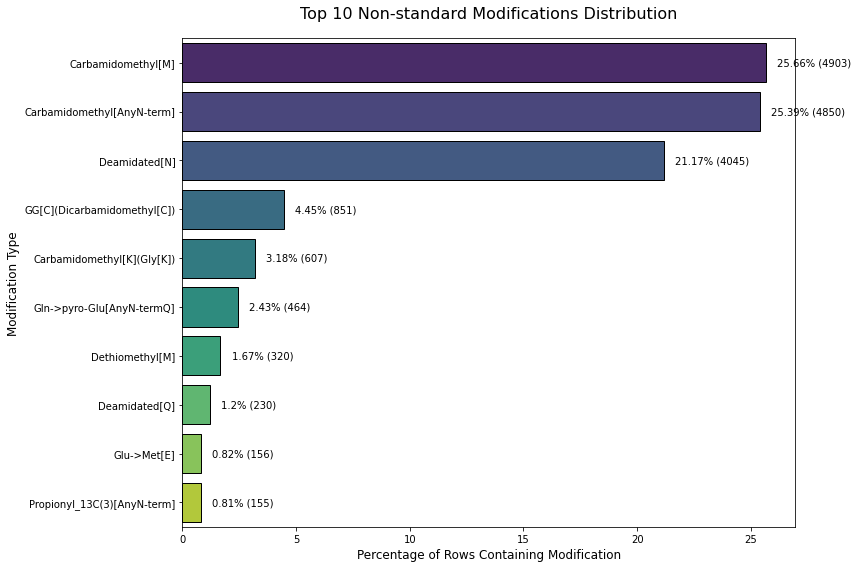

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 确保已安装必要的库
# !pip install matplotlib seaborn

def visualize_mod_stats(mod_stats, top_n=10, save_path='top_non_standard_mods.png'):
    """可视化前N种非标准修饰的分布"""
    # 选取前N种修饰
    top_mods = mod_stats.head(top_n).copy()
    
    # 创建图表
    plt.figure(figsize=(12, 8))
    
    # 创建水平条形图
    ax = sns.barplot(
        x='Percentage', 
        y='Modification', 
        data=top_mods,
        palette='viridis',
        edgecolor='black'
    )
    
    # 添加数据标签
    for i, (_, row) in enumerate(top_mods.iterrows()):
        ax.text(
            row['Percentage'] + 0.5,  # x位置
            i,                        # y位置
            f"{row['Percentage']}% ({row['Count']})",
            va='center',
            fontsize=10
        )
    
    # 设置标题和标签
    plt.title(f'Top {top_n} Non-standard Modifications Distribution', fontsize=16, pad=20)
    plt.xlabel('Percentage of Rows Containing Modification', fontsize=12)
    plt.ylabel('Modification Type', fontsize=12)
    
    # 调整布局
    plt.tight_layout()
    
    # 保存图表
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"可视化图表已保存到: {save_path}")
    
    # 显示图表
    plt.show()

# 使用函数进行可视化
visualize_mod_stats(mod_stats, top_n=10)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 读取新的数据框（请替换为实际文件路径）
new_df_path = '/rd1/user/lit/project/sORFs/analysis/20250623_human_ms_rerun/output/db_search_c8_open_search/Trypsin/ptm-shepherd-output/global.modsummary.tsv'  # 修改为实际文件路径
new_df = pd.read_csv(new_df_path, sep='\t')

# 2. 重命名长列名以便操作
new_df = new_df.rename(columns={
    'CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2_3_1_7020_d_PSMs': 'Count',
    'CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2_3_1_7020_d_percent_PSMs': 'Percentage'
})

In [8]:
new_df.head()

,Modification,Mass Shift,Count_other,Percentage_other
0,NaN,0.000000,37092,60.254
1,Iodoacetamide derivative/Addition of Glycine/A...,57.021464,3335,5.417
2,First isotopic peak,1.002350,1984,3.222
3,Deamidation,0.984016,1301,2.111
4,Isotopic peak error,-1.002350,711,1.155


/tmp/ipykernel_4881/1504623974.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


可视化图表已保存到: top_non_standard_mods.png


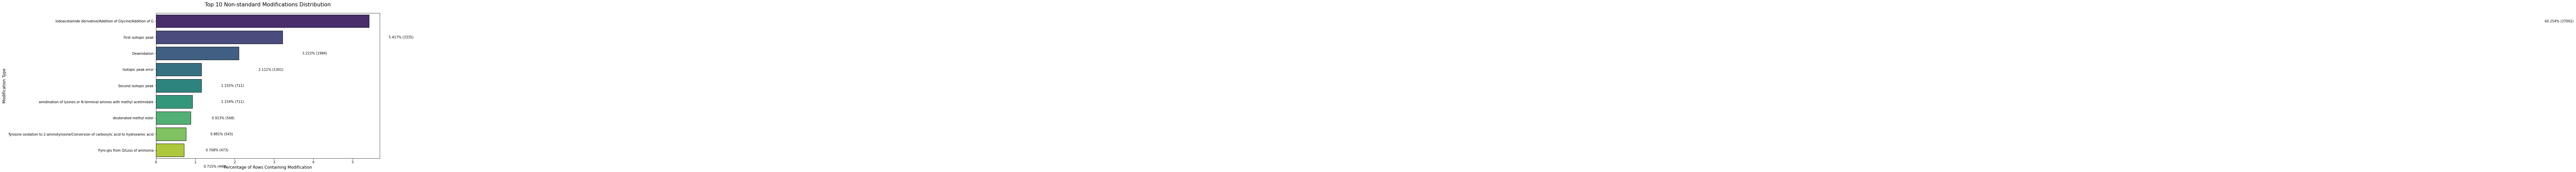

In [11]:
visualize_mod_stats(new_df, top_n=10)